# GSVA pathway heatmap

Remote source reviewed from `20250604p38-afterYZ/GSVA/方格.ipynb`. Run from top to bottom after configuring `config/paths.*`.


In [ ]:
# Centralized paths and scheduler-aware thread limits.
repo_root <- if (file.exists("config/paths.R")) "." else if (file.exists("../config/paths.R")) ".." else stop("Run Jupyter from the repository root or notebooks/ directory.")
source(file.path(repo_root, "config", "paths.R"))


As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
First group.by variable `celltype_condition` starts with a number, appending `g` to ensure valid variable names
This message is displayed once every 8 hours.
! 938 genes with constant values throughout the samples

! Genes with constant values are discarded



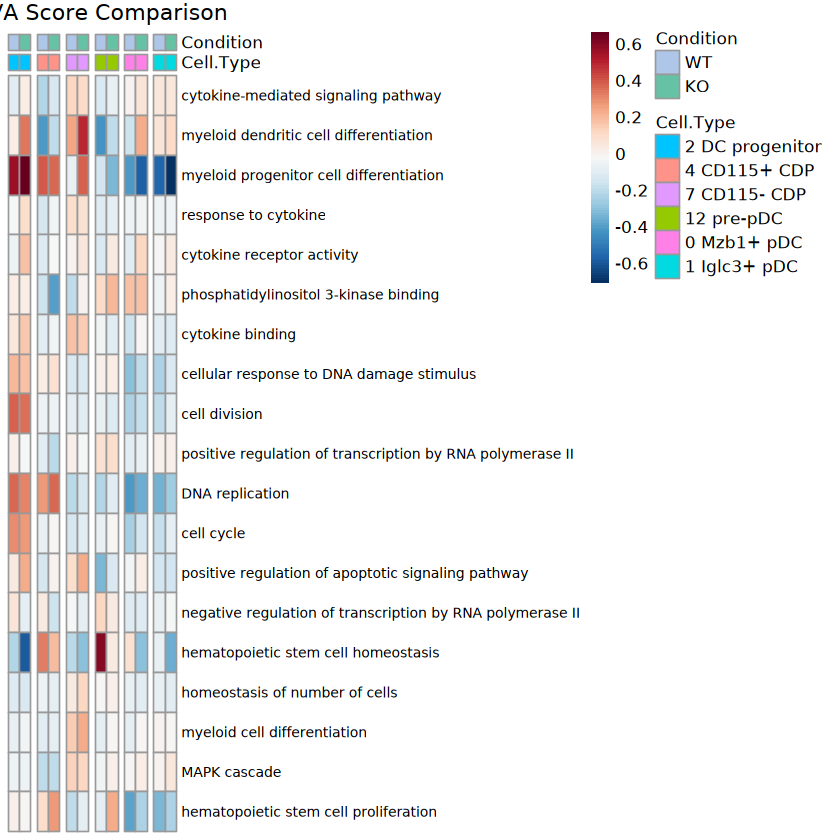

In [1]:
# --------------------------------------------------------------------------
# |                        GSVA 分析与可视化脚本 (pheatmap 版)                 |
# |                                                                        |
# | 核心逻辑：                                                             |
# | 1. 使用 pheatmap 包绘制热图，以获得经典的视觉效果和强大的功能。        |
# | 2. 通过计算 gaps_col 参数，在不同细胞类型之间创建清晰的空隙。          |
# | 3. 所有图例和标题均为英文。                                            |
# --------------------------------------------------------------------------

# 加载必要的 R 包 (新增 pheatmap)
suppressPackageStartupMessages({
    library(GSVA)
    library(msigdbr)
    library(Seurat)
    library(dplyr)
    library(tibble)
    library(pheatmap) # <-- 新增
    library(RColorBrewer) # <-- 用于创建颜色
})

# --- 1-4. 数据加载与处理 (与之前完全相同) ---
seu <- readRDS(legacy_path("20250604p38-afterYZ/anno.rds"))
mac_clusters_original <- c(
  "2 DC progenitor", "4 CD115+ CDP", "7 CD115- CDP",
  "12 pre-pDC", "0 Mzb1+ pDC", "1 Iglc3+ pDC"
)
mac_cells <- subset(seu, subset = celltype %in% mac_clusters_original)
mac_cells$celltype_condition <- paste(mac_cells$celltype, mac_cells$orig.ident, sep = "-")
Idents(mac_cells) <- "celltype_condition"

GenesetsOfInterest_ids <- c(
  "GO:0030097", "GO:0019221", "GO:0043011", "GO:0002318", "GO:0034097",
  "GO:0004896", "GO:0043548", "GO:0019955", "GO:0006974", "GO:0051301",
  "GO:0045944", "GO:0006260", "GO:0045893", "GO:0007049", "GO:2001235",
  "GO:0000122", "GO:0000086", "GO:0061484", "GO:0048872", "GO:0030099",
  "GO:0000165", "GO:0071425"
)
GenesetsOfInterest_ids <- unique(GenesetsOfInterest_ids)
go_to_description_map <- c(
  "GO:0030097" = "hemopoiesis",
  "GO:0019221" = "cytokine-mediated signaling pathway",
  "GO:0043011" = "myeloid dendritic cell differentiation",
  "GO:0002318" = "myeloid progenitor cell differentiation",
  "GO:0034097" = "response to cytokine",
  "GO:0004896" = "cytokine receptor activity",
  "GO:0043548" = "phosphatidylinositol 3-kinase binding",
  "GO:0019955" = "cytokine binding",
  "GO:0006974" = "cellular response to DNA damage stimulus",
  "GO:0051301" = "cell division",
  "GO:0045944" = "positive regulation of transcription by RNA polymerase II",
  "GO:0006260" = "DNA replication",
  "GO:0045893" = "positive regulation of DNA-templated transcription",
  "GO:0007049" = "cell cycle",
  "GO:2001235" = "positive regulation of apoptotic signaling pathway",
  "GO:0000122" = "negative regulation of transcription by RNA polymerase II",
  "GO:0000086" = "G2/M transition of mitotic cell cycle",
  "GO:0061484" = "hematopoietic stem cell homeostasis",
  "GO:0048872" = "homeostasis of number of cells",
  "GO:0030099" = "myeloid cell differentiation",
  "GO:0000165" = "MAPK cascade",
  "GO:0071425" = "hematopoietic stem cell proliferation"
)

c5_all <- msigdbr(species = "Mus musculus", category = "C5") 
c2 <- msigdbr(species = "Mus musculus", category = "C2") 
h <- msigdbr(species = "Mus musculus", category = "H")
gs2gene <- rbind(c2, c5_all, h)

GenesetsOfInterest.list <- list()
for (gs in GenesetsOfInterest_ids) {
  glist <- unique((gs2gene %>% dplyr::filter(gs_exact_source == gs))$gene_symbol)
  if (length(glist) == 0) { glist <- unique((gs2gene %>% dplyr::filter(gs_name == gs))$gene_symbol) }
  if(length(glist) > 0) { GenesetsOfInterest.list[[gs]] <- glist }
}

# --- 5. GSVA 分析 ---
DefaultAssay(mac_cells) <- "RNA"
mac_cells <- NormalizeData(mac_cells, verbose = FALSE)
mac_cells.bulk <- AverageExpression(mac_cells, assays = "RNA", layer = "data", group.by = "celltype_condition", verbose = FALSE)
expr_matrix <- as.matrix(mac_cells.bulk$RNA)
param <- gsvaParam(expr = expr_matrix, geneSets = GenesetsOfInterest.list, kcdf = "Gaussian")
mac_cells.bulk.gsva <- gsva(param, verbose = FALSE) 

# --- 6. 准备 pheatmap 需要的数据 ---
final_pathways_in_gsva <- intersect(names(GenesetsOfInterest.list), rownames(mac_cells.bulk.gsva))
ordered_final_pathways_ids <- GenesetsOfInterest_ids[GenesetsOfInterest_ids %in% final_pathways_in_gsva]
gsva_matrix <- mac_cells.bulk.gsva[ordered_final_pathways_ids, , drop = FALSE]

# -- 准备列注释 (annotation_col) --
columns <- colnames(gsva_matrix) 
celltype_annotations <- character(length(columns)); condition_annotations <- character(length(columns))
condition_pattern <- "(WT|KO)$"
for (i in 1:length(columns)) {
  col_name <- sub("^g", "", columns[i])
  if (grepl(condition_pattern, col_name)) {
    condition_annotations[i] <- regmatches(col_name, regexpr(condition_pattern, col_name))
    celltype_annotations[i] <- sub(paste0("-?", condition_annotations[i], "$"), "", col_name)
  } else { 
      condition_annotations[i] <- "Unknown"; celltype_annotations[i] <- col_name; 
      warning(paste("Could not parse:", columns[i])) 
  }
}
celltype_annotations <- trimws(celltype_annotations); condition_annotations <- trimws(condition_annotations)
unique_celltypes_parsed <- unique(celltype_annotations)
ordered_celltypes_for_plotting <- mac_clusters_original[mac_clusters_original %in% unique_celltypes_parsed]
condition_order <- c("WT", "KO")

# 创建用于排序的完整数据框
annotation_df_full <- data.frame(
  Sample = columns,
  Celltype = factor(celltype_annotations, levels = ordered_celltypes_for_plotting),
  Condition = factor(condition_annotations, levels = condition_order)
)
# 根据细胞类型和分组排序，获取排好序的样本名
ordered_samples <- annotation_df_full %>%
  arrange(Celltype, Condition) %>%
  pull(Sample)

# 根据排好序的样本名，创建 pheatmap 需要的 annotation_col
# 只包含需要注释的列，并且行名是样本名
annotation_col <- data.frame(
  `Cell Type` = factor(celltype_annotations, levels = ordered_celltypes_for_plotting),
  Condition = factor(condition_annotations, levels = condition_order),
  row.names = columns
)

# 对主矩阵 `gsva_matrix` 的列进行排序
gsva_matrix_sorted <- gsva_matrix[, ordered_samples]

# -- 准备行标签 (可读的通路名) --
readable_rownames <- go_to_description_map[rownames(gsva_matrix_sorted)]
# 安全检查，防止有NA
readable_rownames[is.na(readable_rownames)] <- rownames(gsva_matrix_sorted)[is.na(readable_rownames)]

# -- 准备注释颜色 (annotation_colors) --
celltype_colors <- c("2 DC progenitor" = "#FFA500", "4 CD115+ CDP" = "#32CD32", "7 CD115- CDP" = "#9932CC", "12 pre-pDC" = "#1E90FF", "0 Mzb1+ pDC" = "#00AEEF", "1 Iglc3+ pDC" = "#66CCFF")
condition_colors <- c("WT" = "#AEC7E8", "KO" = "#66C2A5")
annotation_colors <- list(
  `Cell Type` = celltype_colors[names(celltype_colors) %in% unique(annotation_col$`Cell Type`)],
  Condition = condition_colors
)

# -- 计算空隙位置 (gaps_col) --
# 空隙应该在每个细胞类型组之后
gap_positions <- (1:(length(ordered_celltypes_for_plotting) - 1)) * length(condition_order)


# --- 7. 绘制 pheatmap 热图 ---
pheatmap(
  gsva_matrix_sorted,
  
  # 外观和标签
  main = "GSVA Score Comparison", # 英文总标题
  labels_row = readable_rownames,
  labels_col = FALSE, # 不显示列标签 (样本全名)
  fontsize_row = 8,
  fontsize = 10,
  
  # 聚类与排序
  cluster_cols = FALSE, # 我们已经手动排序，所以关闭列聚类
  cluster_rows = FALSE, # 按我们提供的顺序显示通路
  
  # 注释
  annotation_col = annotation_col,
  annotation_colors = annotation_colors,
  
  # 颜色映射
  color = colorRampPalette(rev(brewer.pal(n = 11, name = "RdBu")))(100),
  
  # 空隙
  gaps_col = gap_positions,
  
  # 其他美化参数
  border_color = "grey60",
  show_colnames = FALSE
)